# A/B Test Case Study: ANOVA in a Food Delivery App

Your colleague ran two A/B experiments and suspects differences between groups exist.
Your task: select the appropriate method, verify statistical assumptions, run the tests, and support the business decision.

**Case 1 — Photo Format (One-Way ANOVA)**  
Three photo formats for dish images were tested: rectangular 16:9 (A), square (B), and rectangular 12:4 (C).  
Goal: determine which format leads to the highest number of order events.

**Case 2 — Order Button Redesign (Two-Way ANOVA)**  
A new order button design was tested across two customer segments (high and low activity).  
Goal: measure the effect of the redesign and customer segment on the number of events, including their interaction.

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.special import comb
import statsmodels.formula.api as smf
from statsmodels.stats.api import anova_lm
import pingouin as pg
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

---
## Part 1: One-Way ANOVA — Photo Format vs. Orders

Users were shown dish photos in one of three formats; their activity (events) was recorded.

### Dataset Description

| Column | Type | Description |
|--------|------|-------------|
| `id` | int | Unique user identifier |
| `group` | str | Photo format: `A` (16:9 rectangular), `B` (square), `C` (12:4 rectangular) |
| `events` | int | Number of order events |

## 1. Dataset Overview

In [139]:
data = pd.read_csv("data/5_task_1.csv")
print(f'Shape: {data.shape}')
data.head()

Shape: (30000, 3)


,id,group,events
0,16046,A,14
1,18712,A,41
2,3268,A,30
3,22633,A,37
4,28071,A,38


In [140]:
data.info()
print()
print('Group sizes:')
print(data['group'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      30000 non-null  int64
 1   group   30000 non-null  str  
 2   events  30000 non-null  int64
dtypes: int64(2), str(1)
memory usage: 703.3 KB

Group sizes:
group
A    10000
B    10000
C    10000
Name: count, dtype: int64


In [141]:
A = data.query("group == 'A'").events
B = data.query("group == 'B'").events
C = data.query("group == 'C'").events

print('Group means:')
print(f'  A (16:9 rectangular): {A.mean():.2f}')
print(f'  B (square):           {B.mean():.2f}')
print(f'  C (12:4 rectangular): {C.mean():.2f}')

Group means:
  A (16:9 rectangular): 29.58
  B (square):           37.61
  C (12:4 rectangular): 27.47


## 2. Visual Exploration

Before running statistical tests, visualize group distributions to form initial expectations.

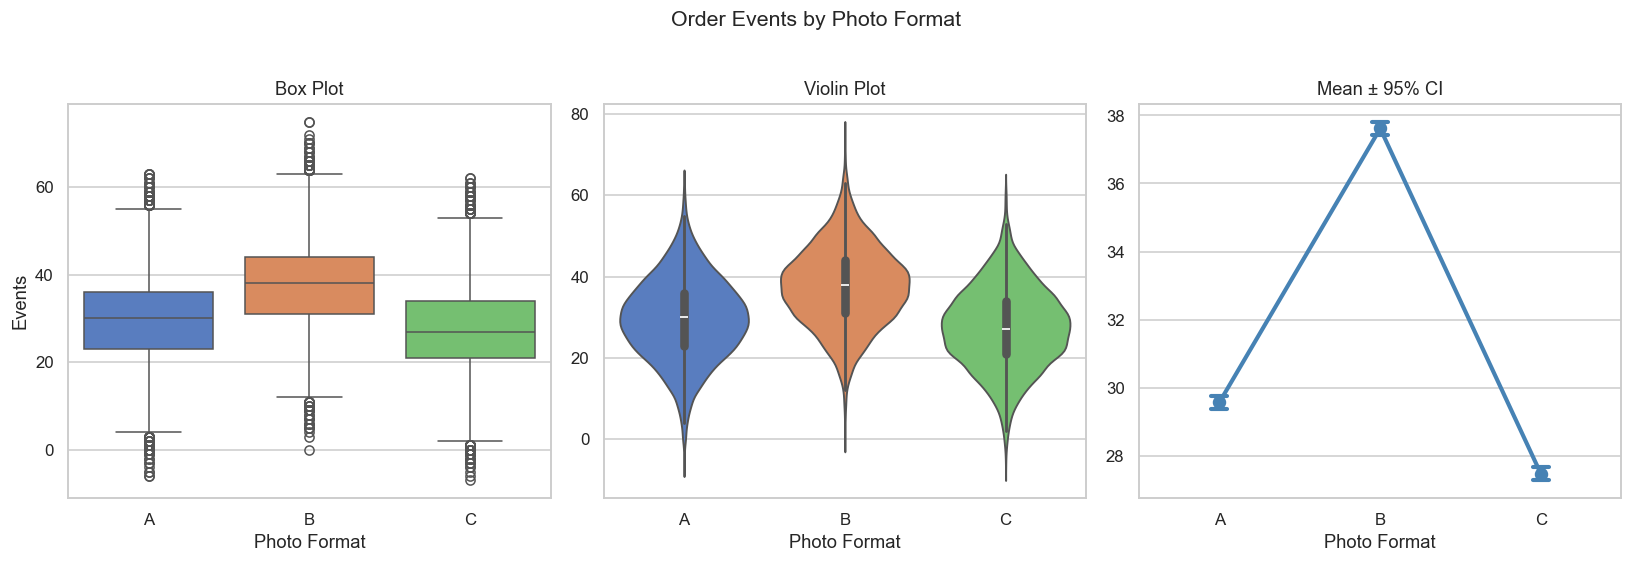

In [142]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(x='group', y='events', hue='group', data=data, ax=axes[0], legend=False)
axes[0].set_title('Box Plot')
axes[0].set_xlabel('Photo Format')
axes[0].set_ylabel('Events')

sns.violinplot(x='group', y='events', hue='group', data=data, ax=axes[1], legend=False)
axes[1].set_title('Violin Plot')
axes[1].set_xlabel('Photo Format')
axes[1].set_ylabel('')

sns.pointplot(x='group', y='events', data=data, ax=axes[2], color='steelblue', capsize=0.1)
axes[2].set_title('Mean \u00b1 95% CI')
axes[2].set_xlabel('Photo Format')
axes[2].set_ylabel('')

plt.suptitle('Order Events by Photo Format', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3. ANOVA Assumptions: Normality

One-Way ANOVA requires the data within each group to be approximately normally distributed.

- **Shapiro-Wilk** — reliable for small samples; tends to over-reject for $n > 50$, so use a sample of 1000
- **D'Agostino-Pearson** (`normaltest`) — designed for larger samples, tests skewness and kurtosis jointly
- **QQ plot** — visual check; deviations from the diagonal line indicate non-normality

In [143]:
print('Shapiro-Wilk test (note: can over-reject for n > 50):')
for name, group in [('A', A), ('B', B), ('C', C)]:
    sample = group.sample(1000, random_state=17)
    result = stats.shapiro(sample)
    print(f'  {name}: W={result.statistic:.4f}, p={result.pvalue:.4f} => {"normal" if result.pvalue > 0.05 else "non-normal"}')

Shapiro-Wilk test (note: can over-reject for n > 50):
  A: W=0.9973, p=0.0959 => normal
  B: W=0.9981, p=0.3187 => normal
  C: W=0.9981, p=0.3366 => normal


In [144]:
# D'Agostino-Pearson test via pingouin
pg.normality(data=data, dv='events', group='group', method='normaltest')

,W,pval,normal
group,,,
A,2.103460,0.349333,True
B,0.841072,0.656695,True
C,3.243726,0.197530,True


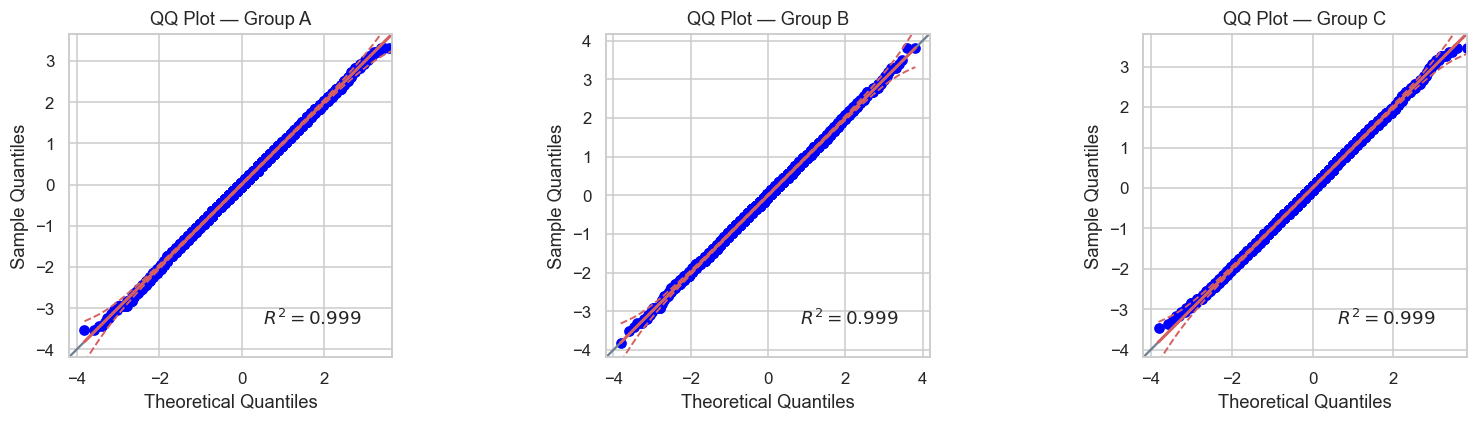

In [145]:
# QQ plots — visual normality check for each group
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, group) in zip(axes, [('A', A), ('B', B), ('C', C)]):
    pg.qqplot(group, ax=ax)
    ax.set_title(f'QQ Plot \u2014 Group {name}')
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Sample Quantiles')

plt.tight_layout()
plt.show()

## 4. ANOVA Assumptions: Homogeneity of Variance

Standard ANOVA assumes equal variances across groups (homoscedasticity).

**Levene's test:**
- $H_0$: all group variances are equal
- $H_1$: at least one group has a different variance

If $p > 0.05$, variances are homogeneous and standard ANOVA applies.

In [146]:
# Levene's test via scipy
result_lev = stats.levene(A, B, C)
print(f'Levene statistic: {result_lev.statistic:.4f}')
print(f'P-value:          {result_lev.pvalue:.4f}')
print(f"=> {'Equal variances (homoscedastic)' if result_lev.pvalue > 0.05 else 'Unequal variances'}")

Levene statistic: 2.2623
P-value:          0.1041
=> Equal variances (homoscedastic)


In [147]:
# Levene's test via pingouin
pg.homoscedasticity(data=data, dv="events", group="group")

,W,pval,equal_var
levene,2.26226,0.104133,True


## 5. One-Way ANOVA

**When to use:** comparing means across 3 or more groups simultaneously.
Running multiple pairwise t-tests inflates the Type I error rate — ANOVA avoids this by testing all groups at once.

**Hypotheses:**
- $H_0$: all group means are equal ($\mu_A = \mu_B = \mu_C$)
- $H_1$: at least one group mean differs

Significance level: $\alpha = 0.05$

In [148]:
# One-Way ANOVA via pingouin (includes partial eta-squared effect size)
pg.anova(data=data, dv="events", between="group")

,Source,ddof1,ddof2,F,p_unc,np2
0,group,2,29997,2886.166657,0.0,0.161377


## 6. Post-hoc Pairwise Comparisons

ANOVA only tells us *that* at least one group differs — not *which* groups.
Post-hoc tests identify where the differences lie while controlling for the multiple comparisons problem.

| Method | Description |
|--------|-------------|
| **Tukey HSD** | Controls family-wise error rate; robust for equal group sizes |
| **Games-Howell** | Preferred when group variances are unequal |
| **Holm-Bonferroni** | Step-down correction; less conservative than Bonferroni |
| **Benjamini-Hochberg** | Controls false discovery rate; most sensitive |

In [150]:
# Tukey HSD
pg.pairwise_tukey(data=data, dv="events", between="group")

,A,B,mean_A,mean_B,diff,se,T,p_tukey,hedges
0,A,B,29.5796,37.6136,-8.0340,0.140894,-57.021604,5.026313e-12,-0.806229
1,A,C,29.5796,27.4703,2.1093,0.140894,14.970833,5.026313e-12,0.210514
2,B,C,37.6136,27.4703,10.1433,0.140894,71.992436,5.026313e-12,1.024138


In [151]:
# Games-Howell (does not assume equal variances)
pg.pairwise_gameshowell(data=data, dv="events", between="group")

,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,A,B,29.5796,37.6136,-8.0340,0.140920,-57.011134,19987.258491,2.473022e-12,-0.806229
1,A,C,29.5796,27.4703,2.1093,0.141696,14.886135,19995.116233,6.349254e-12,0.210514
2,B,C,37.6136,27.4703,10.1433,0.140062,72.420220,19995.502469,0.000000e+00,1.024138


In [152]:
# Holm-Bonferroni correction
pg.pairwise_tests(data=data, dv="events", between="group", padjust="holm")

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,hedges
0,group,A,B,False,True,-57.011134,19998.0,two-sided,0.000000e+00,0.000000e+00,holm,inf,-0.806229
1,group,A,C,False,True,14.886135,19998.0,two-sided,7.500262e-50,7.500262e-50,holm,1.054e+46,0.210514
2,group,B,C,False,True,72.420220,19998.0,two-sided,0.000000e+00,0.000000e+00,holm,inf,1.024138


In [153]:
# Benjamini-Hochberg (FDR) correction
pg.pairwise_tests(data=data, dv="events", between="group", padjust="fdr_bh")

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,hedges
0,group,A,B,False,True,-57.011134,19998.0,two-sided,0.000000e+00,0.000000e+00,fdr_bh,inf,-0.806229
1,group,A,C,False,True,14.886135,19998.0,two-sided,7.500262e-50,7.500262e-50,fdr_bh,1.054e+46,0.210514
2,group,B,C,False,True,72.420220,19998.0,two-sided,0.000000e+00,0.000000e+00,fdr_bh,inf,1.024138


**Part 1 Summary:**
- ANOVA strongly rejects $H_0$ ($F \approx 2886$, $p \approx 0$)
- Photo format explains ~16% of total variance in events ($\eta^2 = 0.16$)
- Post-hoc tests confirm all three groups differ significantly — results are consistent across all correction methods
- **Group B (square photos)** has the highest mean events (~37.6) vs A (~29.6) and C (~27.5)
- Effect size: B vs C ≈ 1.02 (large), B vs A ≈ 0.81 (large)
- **Decision: use square photo format (Group B)**

---
## Part 2: Two-Way ANOVA — Order Button Redesign

Two-Way ANOVA tests the effect of **two categorical factors** simultaneously and detects whether they **interact**.
Here we examine how the button redesign affects events across two customer segments.

### Dataset Description

| Column | Type | Description |
|--------|------|-------------|
| `id` | int | Unique user identifier |
| `group` | str | Button variant: `control` (old design) or `test` (new design) |
| `segment` | str | Customer activity segment: `high` or `low` |
| `events` | float | Number of order events |

## 7. Dataset Overview

In [154]:
data2 = pd.read_csv("data/5_task_2.csv")
print(f'Shape: {data2.shape}')
data2.head()

Shape: (100000, 4)


,id,group,segment,events
0,83440,test,high,78.0
1,96723,test,high,71.0
2,68719,test,high,80.0
3,50399,test,high,80.0
4,95613,test,high,78.0


In [155]:
data2.info()
print()
print('Unique values per column:')
print(data2.apply(lambda x: x.nunique()))

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  int64  
 1   group    100000 non-null  str    
 2   segment  100000 non-null  str    
 3   events   100000 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 3.1 MB

Unique values per column:
id         100000
group           2
segment         2
events         97
dtype: int64


## 8. Visual Exploration

Visualize the distribution of events separately for the control and test groups.

/var/folders/xf/ygl5_zk57kn1rh2h1xj9fyx40000gn/T/ipykernel_74010/2197906633.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Segment')
/var/folders/xf/ygl5_zk57kn1rh2h1xj9fyx40000gn/T/ipykernel_74010/2197906633.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Segment')


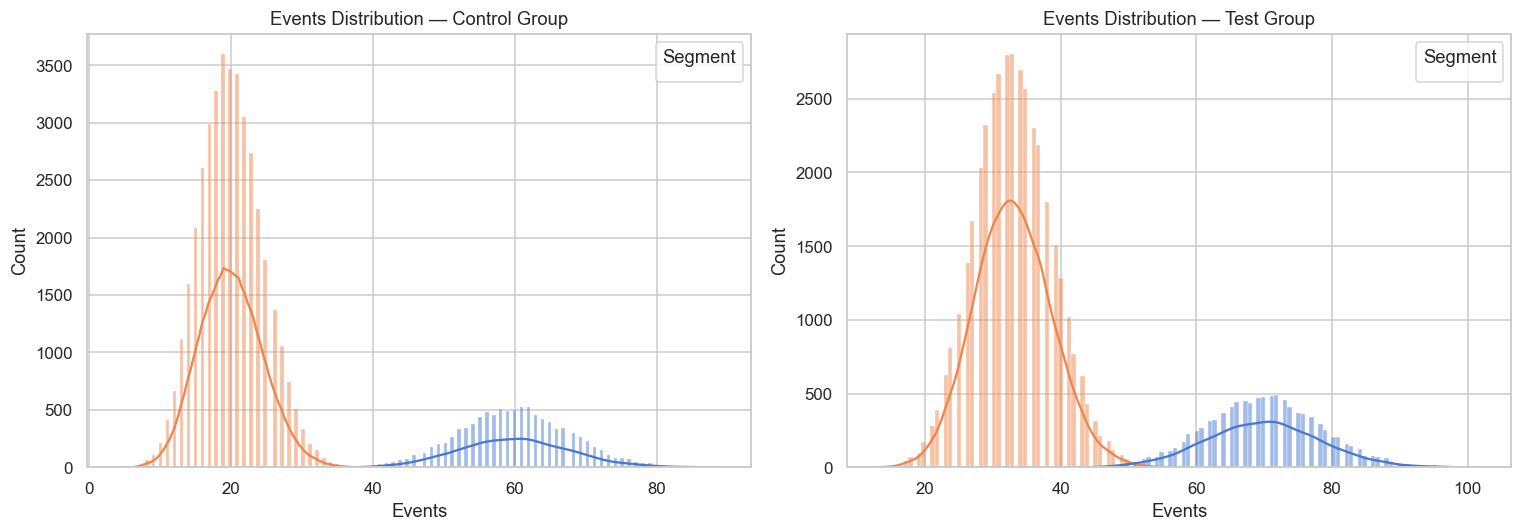

In [156]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, group in zip(axes, ['control', 'test']):
    sns.histplot(
        x='events', hue='segment',
        data=data2.query(f'group == "{group}"'),
        ax=ax, kde=True, alpha=0.5
    )
    ax.set_title(f'Events Distribution \u2014 {group.capitalize()} Group')
    ax.set_xlabel('Events')
    ax.legend(title='Segment')

plt.tight_layout()
plt.show()

## 9. Descriptive Statistics

Compute mean, median, and standard deviation of events broken down by group and customer segment.

In [157]:
data2.groupby(["group", "segment"], as_index=False)\
    .agg({'events': [np.mean, np.std, np.median]})\
    .round(2)

group segment events             
                     mean   std median
0  control    high  59.97  7.80   60.0
1  control     low  20.03  4.47   20.0
2     test    high  69.94  8.40   70.0
3     test     low  33.03  5.72   33.0

## 10. Two-Way ANOVA

Two-Way ANOVA tests:
1. **Main effect of `group`** — does the button redesign affect events on average?
2. **Main effect of `segment`** — do high/low activity segments differ on average?
3. **Interaction `group × segment`** — does the effect of the redesign depend on the customer segment?

$$\text{events} \sim \text{group} \times \text{segment} = \text{group} + \text{segment} + \text{group} : \text{segment}$$

If the interaction term is significant, the main effects alone cannot tell the full story.

In [158]:
# Two-Way ANOVA via pingouin (includes partial eta-squared per factor)
pg.anova(data=data2, dv='events', between=['group', 'segment'])

,Source,SS,DF,MS,F,p_unc,np2
0,group,3.837195e+06,1.0,3.837195e+06,112031.864119,0.000000e+00,0.528383
1,segment,2.362480e+07,1.0,2.362480e+07,689756.377484,0.000000e+00,0.873383
2,group * segment,3.664244e+04,1.0,3.664244e+04,1069.823273,2.060261e-233,0.010585
3,Residual,3.424956e+06,99996.0,3.425093e+01,NaN,NaN,NaN


## 11. Post-hoc Pairwise Comparisons

To identify which specific group-segment combinations differ, combine `group` and `segment` into a single factor and apply Tukey HSD.

| group | segment | combination |
|-------|---------|-------------|
| test | high | test/high |
| control | low | control/low |

In [ ]:
data2['combination'] = data2['group'] + '/' + data2['segment']
data2.head()

,id,group,segment,events,combination
0,83440,test,high,78.0,test/high
1,96723,test,high,71.0,test/high
2,68719,test,high,80.0,test/high
3,50399,test,high,80.0,test/high
4,95613,test,high,78.0,test/high


In [160]:
# Tukey HSD on all group-segment combinations
pg.pairwise_tukey(data=data2, dv="events", between='combination')

,A,B,mean_A,mean_B,diff,se,T,p_tukey,hedges
0,control/high,control/low,59.970800,20.031575,39.939225,0.065432,610.391461,0.0,7.521612
1,control/high,test/high,59.970800,69.938500,-9.967700,0.082766,-120.432523,0.0,-1.228989
2,control/high,test/low,59.970800,33.025925,26.944875,0.065432,411.798717,0.0,4.350026
3,control/low,test/high,20.031575,69.938500,-49.906925,0.065432,-762.727892,0.0,-9.091140
4,control/low,test/low,20.031575,33.025925,-12.994350,0.041383,-314.002699,0.0,-2.530414
5,test/high,test/low,69.938500,33.025925,36.912575,0.065432,564.135148,0.0,5.814008


## 12. Visualizing the Interaction

An interaction plot shows how the effect of one factor changes across levels of the other.
**Non-parallel lines** indicate a statistically significant interaction effect.

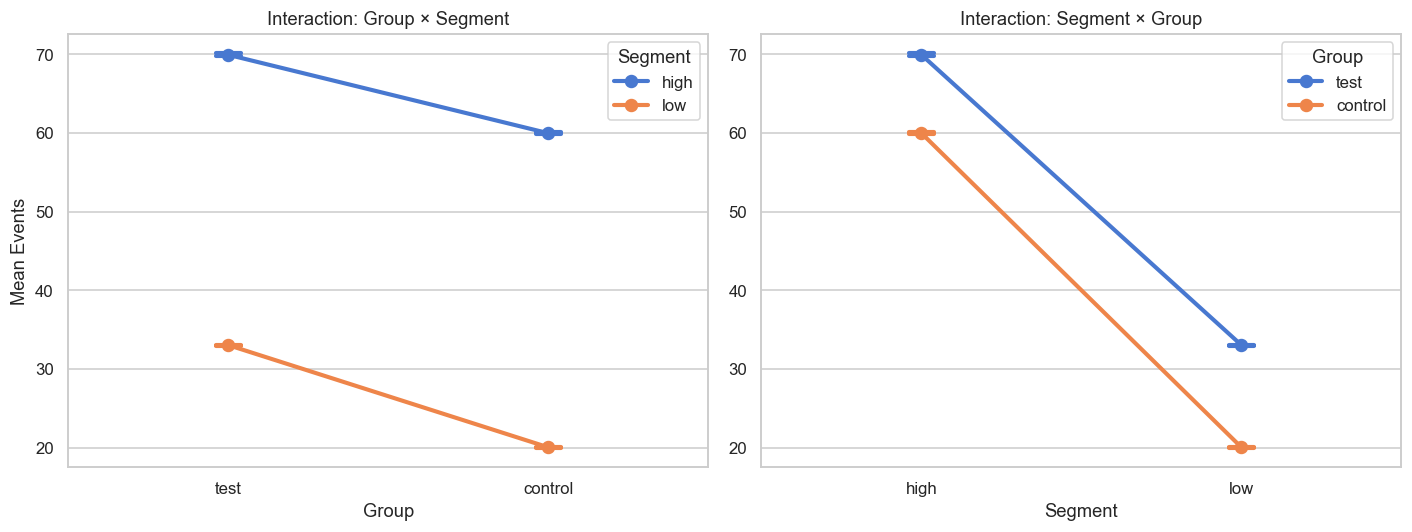

In [162]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.pointplot(
    x='group', y='events', hue='segment',
    data=data2, ax=axes[0], capsize=0.08,
    palette='muted'
)
axes[0].set_title('Interaction: Group \u00d7 Segment')
axes[0].set_xlabel('Group')
axes[0].set_ylabel('Mean Events')
axes[0].legend(title='Segment')

sns.pointplot(
    x='segment', y='events', hue='group',
    data=data2, ax=axes[1], capsize=0.08,
    palette='muted'
)
axes[1].set_title('Interaction: Segment \u00d7 Group')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('')
axes[1].legend(title='Group')

plt.tight_layout()
plt.show()

## Conclusion

### Part 1: One-Way ANOVA — Photo Format

- ANOVA strongly rejects $H_0$ ($F \approx 2886$, $p \approx 0$)
- **Square format (B)** generates significantly more events than both A and C
- All post-hoc methods (Tukey, Games-Howell, Holm, FDR) agree on all pairwise differences
- ANOVA assumptions satisfied: normality confirmed by Shapiro-Wilk and D'Agostino-Pearson; variances are homogeneous (Levene $p \approx 0.10$)
- **Decision: roll out square photos (Group B)**

### Part 2: Two-Way ANOVA — Button Redesign

- Both `group` and `segment` are highly significant main effects
- The **interaction `group × segment` is significant** — the effect of the redesign differs by segment
- Post-hoc Tukey confirms all four combinations differ significantly
- For both segments, mean events **increased** in the test group vs. control (~10 events for `high`, ~13 for `low`)
- **Decision: roll out the new button design**